# Save data files of daily precipitation that are spatially averaged over the VICWaCI regions
Modified from: https://github.com/DamienIrving/VicWaCI/blob/master/agcd_monthly.ipynb

In [7]:
import glob
from pathlib import Path
import numpy as np
import xarray as xr
import geopandas as gp
import regionmask
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

## Read AGCD precipitation data

In [ ]:
agcd_files = sorted(
    glob.glob(
        "/g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_*.nc"
    )
)

In [3]:
def preprocess(ds):
    """Preprocess the AGCD dataset."""

    # Select only the "precip" variable (drops other variables like "lon_bnds", etc)
    ds = ds[["precip"]]

    # Select the region of interest (Victoria, Australia)
    ds = ds.sel(lat=slice(-39.5, -33.5), lon=slice(140, 151))

    # Round the lat/lon coordinates to the nearest 0.05 degrees
    lat_rounded = np.round(
        np.arange(float(ds.lat.values[0]), float(ds.lat.values[-1]) + 0.01, 0.05),
        decimals=2,
    )
    lon_rounded = np.round(
        np.arange(float(ds.lon.values[0]), float(ds.lon.values[-1]) + 0.01, 0.05),
        decimals=2,
    )
    ds = ds.assign_coords(
        lat=("lat", lat_rounded, ds["lat"].attrs),
        lon=("lon", lon_rounded, ds["lon"].attrs),
    )

    return ds


ds = xr.open_mfdataset(agcd_files, chunks="auto", preprocess=preprocess)
ds

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 46021, lat: 121, lon: 221)
Coordinates:
  * time     (time) datetime64[ns] 368kB 1900-01-01T09:00:00 ... 2025-12-31T0...
  * lat      (lat) float64 968B -39.5 -39.45 -39.4 -39.35 ... -33.6 -33.55 -33.5
  * lon      (lon) float64 2kB 140.0 140.1 140.1 140.2 ... 150.9 150.9 151.0
Data variables:
    precip   (time, lat, lon) float32 5GB dask.array<chunksize=(54, 121, 221), meta=np.ndarray>
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2026-06-05 01:25:29
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2026, ...
    history:

## Apply shapefiles to data

In [ ]:
valid_regions = [
    "victoria",
    "south_east_victoria",
    "south_west_victoria",
    "north_east_victoria",
    "north_west_victoria",
]


def read_shapefile(region_name):
    assert region_name in valid_regions
    gdf = gp.read_file(f"/g/data/xv83/dbi599/vicwaci/shapefiles/{region_name}.shp")
    region = regionmask.from_geopandas(gdf)

    return region


def plot_frac(frac):
    fig = plt.figure(figsize=[8, 4])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    frac.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="Blues")
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    plt.show()


def spatial_mean(ds, region_name, overlap_threshold=0.5):
    """Calculate spatial mean"""

    region = read_shapefile(region_name)
    frac = region.mask_3D_frac_approx(ds).isel(region=0)
    plot_frac(frac)

    weights = np.cos(np.deg2rad(ds["lat"]))
    spatial_mean = ds["precip"].weighted(frac * weights).mean(dim=("lat", "lon"))
    spatial_mean = np.round(spatial_mean, decimals=2)

    spatial_mean = spatial_mean.drop_vars(["region", "abbrevs", "names"])
    spatial_mean = spatial_mean.to_dataset()
    spatial_mean["time"].attrs = {
        "axis": "T",
        "standard_name": "time",
        "long_name": "time",
    }
    spatial_mean["precip"].attrs = {
        "units": "mm",
        "long_name": "spatial mean daily precipitation",
    }
    spatial_mean.attrs = {
        "summary": f"total daily precipitation averaged over the {region_name} region",
        "id": "Australian Gridded Climate Data (AGCD)",
        "attribution": ds.attrs["attribution"],
    }

    region_fname = region_name.replace("_", "-")
    outfile = (
        f"/g/data/xv83/as3189/vicwaci/agcd_v1-0-4_precip_total_{region_fname}_daily_1900-2025.nc"
    )
    spatial_mean.to_netcdf(
        outfile,
        compute=True,
        encoding={"time": {"_FillValue": None}, "precip": {"_FillValue": None}},
    )
    print(outfile)

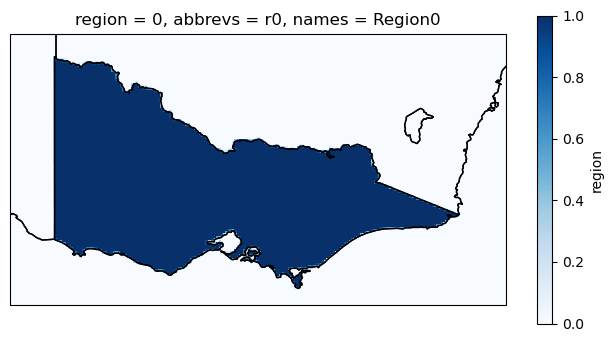

/g/data/xv83/as3189/vicwaci/agcd_v1-0-4_precip_total_victoria_daily_1900-2025.nc


In [10]:
for region in valid_regions:
    spatial_mean(ds, region)